# Classification d'images à l'aide d'algorithmes de Deep Learning

Projet n&#8239;$^\text{o}$ 6 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 23/03/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook de création et d’entraînement du modèle personnel

## Imports et fonctions

In [1]:
DEFAULT_TRGT_IMG_SIZE = (224, 224)
DEFAULT_BATCH_SIZE = 64

import os
# Déclarer le backend avant d'importer keras (sinon par défaut c'est 'tensorflow'):
os.environ["KERAS_BACKEND"] = "torch"
# Memory optimization: Enable expandable segments to reduce fragmentation:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# Limiter la verbosité des logs de tensorflow:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from functions_model_from_scratch import (
    build_model_from_scratch,
    MyKerasSequence,
    plot_accuracy_and_loss_values,
)
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import keras
from keras import layers
from keras.preprocessing import image_dataset_from_directory
# Memory optimization: Use mixed precision (if GPU supports it):
keras.mixed_precision.set_global_policy('mixed_float16')

from collections import Counter
from lxml import etree
from pathlib import Path
from PIL import Image
from pprint import pprint
from sklearn.model_selection import train_test_split
import cv2
import datetime as dt
import joblib
import itertools as it
import matplotlib.pyplot as plt
import numpy as np
import pytz
import seaborn as sns
sns.set()

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

LOGGER_FORMAT = '%(asctime)s [%(levelname)s] %(message)s'
logging.Formatter.converter = lambda *_: dt.datetime.now(pytz.timezone('Europe/Paris')).timetuple()
logging.basicConfig(level=logging.INFO, format=LOGGER_FORMAT, force=True)
logr = logging.getLogger(__name__)
logr.setLevel(logging.DEBUG)
# log_file_handler = logging.FileHandler(f"log/{dt.datetime.isoformat(dt.datetime.now(pytz.timezone('Europe/Paris'))).split('.')[0]}.log")
# log_file_handler.setLevel(logging.DEBUG)
# log_cons_handler = logging.StreamHandler()
# log_cons_handler.setLevel(logging.DEBUG)
# log_file_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# log_cons_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# logr.addHandler(log_file_handler)
# logr.addHandler(log_cons_handler)


## Étapes préliminaires : installer les pilotes GPU et tester l'installation

1. Installer ou mettre à jour le pilote pour la GPU. Par ici pour les GPU Nvidia : https://www.nvidia.com/en-us/drivers/ (spécifier le bon modèle dans le formulaire)

2. Installer le dernier CUDA toolkit (v13.2) de chez Nvidia : 

   - soit de la façon [`runfile (local)`][2] :

     ```bash
     # télécharger l'archive (taille approximative : 4,1 Go)
     wget https://developer.download.nvidia.com/compute/cuda/13.2.0/local_installers/cuda_13.2.0_595.45.04_linux.run

     # exécuter l'archive
     sudo sh cuda_13.2.0_595.45.04_linux.run
     ```

   - soit de la façon [`deb (network)`][3] :

     ```bash
     wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/cuda-keyring_1.1-1_all.deb
     
     sudo dpkg -i cuda-keyring_1.1-1_all.deb
     
     sudo apt update
     
     sudo apt -y install cuda-toolkit-13-2
     ```

3. Ajouter les chemins suivants aux variables d'environnement PATH et LD_LIBRARY_PATH :

     ```bash
     echo 'export PATH=/usr/local/cuda/bin:$PATH' >> ~/.bashrc
     echo 'export LD_LIBRARY_PATH=/usr/local/cuda/lib64:/usr/lib/x86_64-linux-gnu:$LD_LIBRARY_PATH' >> ~/.bashrc

     # Enfin, recharger .bashrc
     source ~/.bashrc
     ```

4. Installer le backend pour Keras (PyTorch, TensorFlow ou JAX) :

   - Pour PyTorch : Suivre [les instructions de la doc PyTorch][1] : Installer le backend `torch` and `torchvision` compatibles CUDA `>=13.0` pour les GPU Nvidia (ou ROCm `>=7.2` pour les GPU AMD).

   - Si besoin, spécifier dans `pyproject.toml` des bornes plus strictes à la version de Python : par exemple, non pas `>=3.12` mais `>=3.12,<3.14`.

5. Installer Keras : Suivre [les instructions de la doc Keras][4]

[1]: https://pytorch.org/get-started/locally/
[2]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=runfile_local
[3]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=deb_network
[4]: https://keras.io/getting_started/

### Tester l'installation de CUDA toolkit et de PyTorch

In [2]:
logr.debug(f"PyTorch version: {torch.__version__}")
logr.debug(f"Is CUDA available: {torch.cuda.is_available()}")
logr.debug(f"CUDA device count: {torch.cuda.device_count()}")
logr.debug(f"Current device: {torch.cuda.current_device()}")
logr.debug(f"Device name: {torch.cuda.get_device_name(0)}")

2026-04-30 19:55:38,684 [DEBUG] PyTorch version: 2.11.0+cu130
2026-04-30 19:55:38,717 [DEBUG] Is CUDA available: True
2026-04-30 19:55:38,740 [DEBUG] CUDA device count: 1
2026-04-30 19:55:38,741 [DEBUG] Current device: 0
2026-04-30 19:55:38,742 [DEBUG] Device name: NVIDIA GeForce RTX 2070 with Max-Q Design


## Entraînement du modèle de prédiction *from scratch*

### 0. Exploration préliminaire

Recenser tous les répertoires contenant les images et les annotations :

In [2]:
img_file_paths = tuple(Path('images/').glob('*/'))
annot_file_paths = tuple(Path('annotations/').glob('*/'))

img_file_paths[0]

PosixPath('images/n02105251-briard')

Les répertoires contenant les images, triés en fonction du nombre d'images :

In [3]:
bag_of_file_counts = {
    dir_path: sum(1 for f in dir_path.iterdir() if f.is_file())
    for dir_path in img_file_paths
}
bag_of_file_counts_sorted_desc = dict(sorted(bag_of_file_counts.items(), reverse=True, key=lambda item: item[1]))
logr.info(f"Les répertoires contenant le plus d'images : {dict(list(bag_of_file_counts_sorted_desc.items())[:5])}")
display(dict(list(bag_of_file_counts_sorted_desc.items())[:5]))
logr.info(f"Les répertoires contenant le moins d'images : {dict(list(bag_of_file_counts_sorted_desc.items())[-5:])}")
display(dict(list(bag_of_file_counts_sorted_desc.items())[-5:]))

2026-05-07 15:31:42,759 [INFO] Les répertoires contenant le plus d'images : {PosixPath('images/n02085936-Maltese_dog'): 252, PosixPath('images/n02088094-Afghan_hound'): 239, PosixPath('images/n02092002-Scottish_deerhound'): 232, PosixPath('images/n02112018-Pomeranian'): 219, PosixPath('images/n02090721-Irish_wolfhound'): 218}


{PosixPath('images/n02085936-Maltese_dog'): 252,
 PosixPath('images/n02088094-Afghan_hound'): 239,
 PosixPath('images/n02092002-Scottish_deerhound'): 232,
 PosixPath('images/n02112018-Pomeranian'): 219,
 PosixPath('images/n02090721-Irish_wolfhound'): 218}

2026-05-07 15:31:42,773 [INFO] Les répertoires contenant le moins d'images : {PosixPath('images/n02115913-dhole'): 150, PosixPath('images/n02106166-Border_collie'): 150, PosixPath('images/n02101556-clumber'): 150, PosixPath('images/n02086079-Pekinese'): 149, PosixPath('images/n02090379-redbone'): 148}


{PosixPath('images/n02115913-dhole'): 150,
 PosixPath('images/n02106166-Border_collie'): 150,
 PosixPath('images/n02101556-clumber'): 150,
 PosixPath('images/n02086079-Pekinese'): 149,
 PosixPath('images/n02090379-redbone'): 148}

### 1. Modèle à 3 classes et ses différentes variantes

Nous allons donc sélectionner trois races selon le nombre d'images mises à notre disposition :

- Deux races contenant le plus d'images : 
  - `Maltese_dog` (252 images) ;
  - `Afghan_hound` (239 images).
- Une race contenant le moins d'images : 
  - `redbone` (148 images)
  
  💡 Ce contraste en termes du nombre d'images peut notamment être intéressant pour souligner ce qu'apporterait à la performance de notre modèle l'ajout de la *data augmentation*.

Nous allons ensuite entraîner différentes variantes de ce modèle :

- Un modèle de base.
- Un modèle avec de la *data augmentation*.
- Un modèle avec un *dropout rate* de `0,15`.
- Un modèle avec un *dropout rate* de `0,30`.
- Un modèle avec un *learning rate* de `1e-4` (au lieu de `1e-3`).
- Un modèle à 3 couches, avec 32, 64, et 128 filtres (au lieu de 32 et 64).
- Un modèle avec une fenêtre de balayage de 5 × 5 (au lieu de 3 × 3).

#### 1.0. Split train - val - test (à lancer avant chaque entraînement)

In [4]:
input_img_paths = tuple(list(bag_of_file_counts_sorted_desc.keys())[i] for i in [-1, 0, 1])
logr.info(f"Les classes retenues : {input_img_paths}")
input_img_paths = tuple(path.glob('*.jpg') for path in input_img_paths)
input_img_paths = tuple(it.chain.from_iterable(input_img_paths))
logr.info(f"Résultat : un tuple de {len(input_img_paths)} images pour les 3 classes de races.")
breed_labels = tuple(str(path).split('/')[1] for path in input_img_paths)
logr.info(f"Distribution des classes : {dict(Counter(breed_labels))}")
display(dict(Counter(breed_labels)))
train_frac = 0.8
input_paths_train, input_paths_val_test, labels_train, labels_val_test = train_test_split(
    input_img_paths, breed_labels, train_size=train_frac,
    random_state=42, shuffle=True, stratify=breed_labels,
)
val_test_frac = 0.5
input_paths_val, input_paths_test, labels_val, labels_test = train_test_split(
    input_paths_val_test, labels_val_test, train_size=val_test_frac,
    random_state=42, shuffle=True, stratify=labels_val_test
)
del input_paths_val_test, labels_val_test
logr.info(f"Train size ({train_frac}): {len(input_paths_train)}")
logr.info(f"Val size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_val)}")
logr.info(f"Test size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_test)}")

2026-05-07 15:31:48,448 [INFO] Les classes retenues : (PosixPath('images/n02090379-redbone'), PosixPath('images/n02085936-Maltese_dog'), PosixPath('images/n02088094-Afghan_hound'))
2026-05-07 15:31:48,456 [INFO] Résultat : un tuple de 639 images pour les 3 classes de races.
2026-05-07 15:31:48,458 [INFO] Distribution des classes : {'n02090379-redbone': 148, 'n02085936-Maltese_dog': 252, 'n02088094-Afghan_hound': 239}


{'n02090379-redbone': 148,
 'n02085936-Maltese_dog': 252,
 'n02088094-Afghan_hound': 239}

2026-05-07 15:31:48,467 [INFO] Train size (0.8): 511
2026-05-07 15:31:48,467 [INFO] Val size (0.1): 64
2026-05-07 15:31:48,468 [INFO] Test size (0.1): 64


In [5]:
train_seq = MyKerasSequence(input_paths_train, labels_train, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE)
val_seq = MyKerasSequence(input_paths_val, labels_val, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE)
test_seq = MyKerasSequence(input_paths_test, labels_test, batch_size=DEFAULT_BATCH_SIZE, target_size=DEFAULT_TRGT_IMG_SIZE)

#### 1.a) Entraînement à 3 classes de base

In [6]:
LR = 1e-3
N_CLASSES = 3
N_EPOCHS = 20
experiment_name = f'CNN_{N_CLASSES}_classes_{N_EPOCHS}_epochs'

Construire le modèle :

In [7]:
model = build_model_from_scratch(
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    experiment_name=experiment_name,
)

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_3_classes_20_epochs"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │   102,760,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,781,891 (392.08 MB)

 Trainable params: 102,781,891 (392.08 MB)

 Non-trainable params: 0 (0.00 B)

None

Entraînement et validation :

In [8]:
torch.cuda.empty_cache()

2026-05-07 15:30:10,517 [INFO] Désérialiser l'objet sauvegardé 'models/from_scratch/CNN_3_classes_20_epochs_model.keras'
2026-05-07 15:30:14,080 [INFO] Désérialiser l'objet sauvegardé 'models/from_scratch/CNN_3_classes_20_epochs_history.joblib'


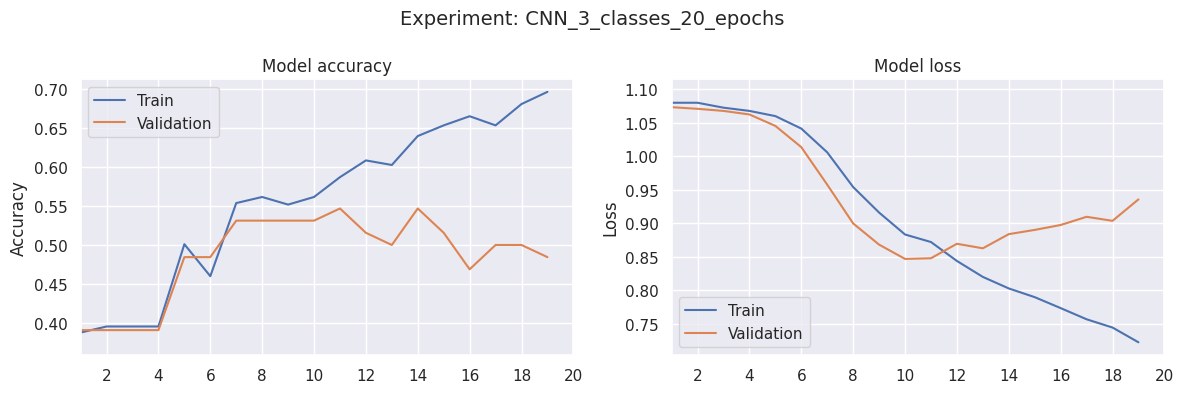

2026-05-07 15:30:20,100 [INFO] Précision finale de l'entraînement: 0.6967
2026-05-07 15:30:20,110 [INFO] Précision finale de la validation: 0.4844
2026-05-07 15:30:20,110 [INFO] Loss finale de l'entraînement: 0.7223
2026-05-07 15:30:20,111 [INFO] Loss finale de la validation: 0.9357


In [9]:
path_to_model = f'models/from_scratch/{experiment_name}_model.keras'
path_to_history = f'models/from_scratch/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location=['upper left', 'lower left'])
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

In [11]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")

2026-04-30 19:50:02,434 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 0.6562 - loss: 0.9065


2026-04-30 19:50:12,036 [INFO] loss, accuracy = [0.9065119028091431, 0.65625]


#### 1.b) Entraînement à 3 classes avec *data augmentation*

In [6]:
LR = 1e-3
N_CLASSES = 3
N_EPOCHS = 20
experiment_name = f'CNN_{N_CLASSES}_classes_{N_EPOCHS}_epochs_data_augm'

Construire le modèle :

In [7]:
data_augm = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomCrop(*DEFAULT_TRGT_IMG_SIZE),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='data_augmentation')

model = build_model_from_scratch(
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    data_augm=data_augm,
    experiment_name=experiment_name,
)

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_3_classes_20_epochs_data_augm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │   102,760,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,781,891 (392.08 MB)

 Trainable params: 102,781,891 (392.08 MB)

 Non-trainable params: 0 (0.00 B)

None

Entraînement et validation :

In [8]:
torch.cuda.empty_cache()

2026-05-07 15:32:09,223 [INFO] Désérialiser l'objet sauvegardé 'models/from_scratch/CNN_3_classes_20_epochs_data_augm_model.keras'
2026-05-07 15:32:29,362 [INFO] Désérialiser l'objet sauvegardé 'models/from_scratch/CNN_3_classes_20_epochs_data_augm_history.joblib'


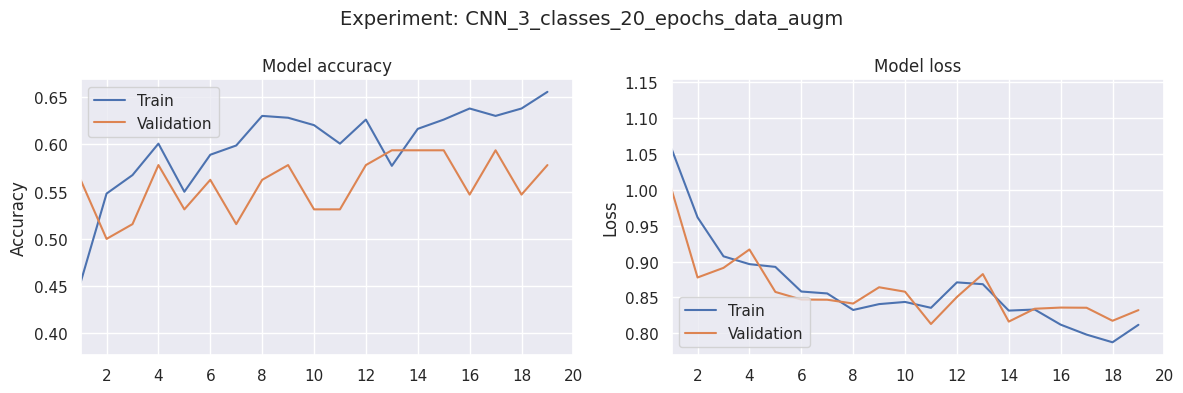

2026-05-07 15:32:52,812 [INFO] Précision finale de l'entraînement: 0.6556
2026-05-07 15:32:52,818 [INFO] Précision finale de la validation: 0.5781
2026-05-07 15:32:52,819 [INFO] Loss finale de l'entraînement: 0.8119
2026-05-07 15:32:52,819 [INFO] Loss finale de la validation: 0.8324


In [9]:
path_to_model = f'models/from_scratch/{experiment_name}_model.keras'
path_to_history = f'models/from_scratch/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location=['upper left', 'lower left'])
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

In [11]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")

2026-04-30 19:53:15,417 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.6406 - loss: 0.7944


2026-04-30 19:53:15,718 [INFO] loss, accuracy = [0.7944326996803284, 0.640625]


#### 1.c) Entraînement à 3 classes avec un *dropout* de 0,15

In [10]:
DROPOUT_RATE = 0.15
LR = 1e-3
N_CLASSES = 3
N_EPOCHS = 20
experiment_name = f'CNN_{N_CLASSES}_classes_{N_EPOCHS}_epochs_{DROPOUT_RATE:.2f}_dropout'

Construire le modèle :

In [11]:
model = build_model_from_scratch(
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name,
)

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_3_classes_20_epochs_0.15_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │   102,760,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,781,891 (392.08 MB)

 Trainable params: 102,781,891 (392.08 MB)

 Non-trainable params: 0 (0.00 B)

None

Entraînement et validation :

In [9]:
torch.cuda.empty_cache()

2026-04-30 19:54:02,504 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_0.15_dropout'...
W0000 00:00:1777571644.532089 2814511 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-04-30 19:55:00,878 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_0.15_dropout' terminé
2026-04-30 19:55:00,878 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_0.15_dropout_model.keras'
2026-04-30 19:55:05,287 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_0.15_dropout_history.joblib'


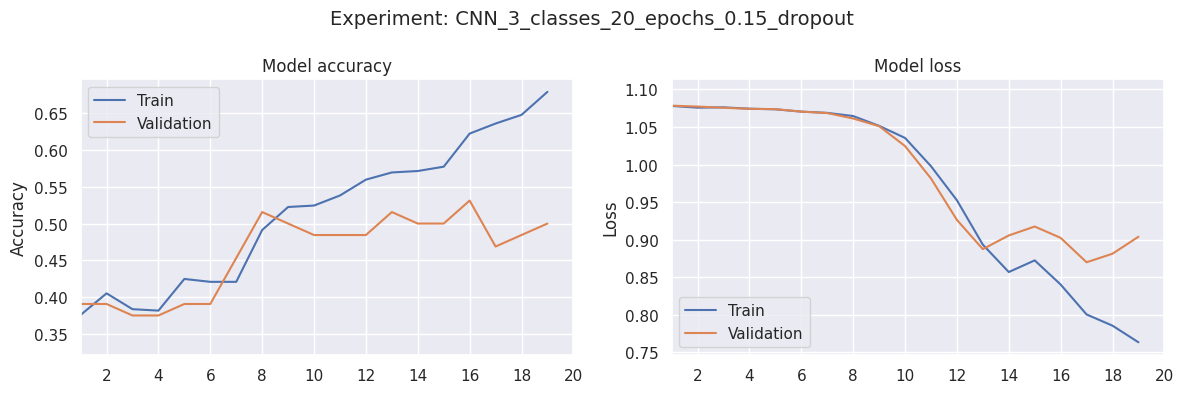

2026-04-30 19:55:13,638 [INFO] Précision finale de l'entraînement: 0.6791
2026-04-30 19:55:13,640 [INFO] Précision finale de la validation: 0.5000
2026-04-30 19:55:13,640 [INFO] Loss finale de l'entraînement: 0.7635
2026-04-30 19:55:13,641 [INFO] Loss finale de la validation: 0.9040


In [ ]:
path_to_model = f'models/from_scratch/{experiment_name}_model.keras'
path_to_history = f'models/from_scratch/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location=['upper left', 'lower left'])
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

In [11]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")

2026-04-30 19:55:13,650 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.6406 - loss: 0.8330


2026-04-30 19:55:13,937 [INFO] loss, accuracy = [0.8330034613609314, 0.640625]


#### 1.d) Entraînement à 3 classes avec un *dropout* de 0,30

In [12]:
DROPOUT_RATE = 0.30
LR = 1e-3
N_CLASSES = 3
N_EPOCHS = 20
experiment_name = f'CNN_{N_CLASSES}_classes_{N_EPOCHS}_epochs_{DROPOUT_RATE:.2f}_dropout'

Construire le modèle :

In [13]:
model = build_model_from_scratch(
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name,
)

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_3_classes_20_epochs_0.30_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │   102,760,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,781,891 (392.08 MB)

 Trainable params: 102,781,891 (392.08 MB)

 Non-trainable params: 0 (0.00 B)

None

Entraînement et validation :

In [10]:
torch.cuda.empty_cache()

2026-04-30 20:00:12,586 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_0.30_dropout'...
W0000 00:00:1777572015.223568 2829425 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-04-30 20:01:12,346 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_0.30_dropout' terminé
2026-04-30 20:01:12,346 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_0.30_dropout_model.keras'
2026-04-30 20:01:17,061 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_0.30_dropout_history.joblib'


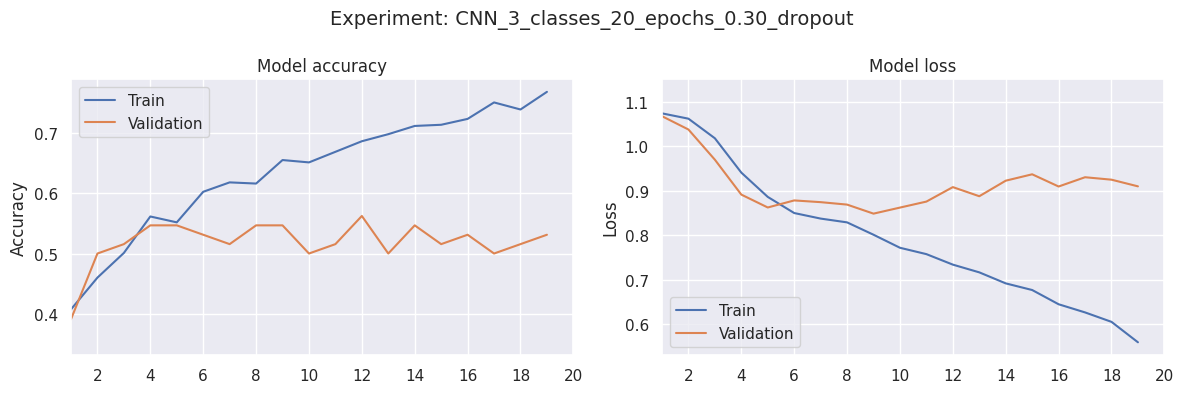

2026-04-30 20:01:24,577 [INFO] Précision finale de l'entraînement: 0.7691
2026-04-30 20:01:24,579 [INFO] Précision finale de la validation: 0.5312
2026-04-30 20:01:24,580 [INFO] Loss finale de l'entraînement: 0.5595
2026-04-30 20:01:24,580 [INFO] Loss finale de la validation: 0.9098


In [ ]:
path_to_model = f'models/from_scratch/{experiment_name}_model.keras'
path_to_history = f'models/from_scratch/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location=['upper left', 'lower left'])
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

In [12]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")

2026-04-30 20:01:25,337 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.6406 - loss: 0.8099


2026-04-30 20:01:33,980 [INFO] loss, accuracy = [0.8098845481872559, 0.640625]


#### 1.e) Entraînement à 3 classes avec un *learning rate* de 0,0001 (au lieu de 0,001)

In [14]:
LR = 1e-4
N_CLASSES = 3
N_EPOCHS = 20
experiment_name = f'CNN_{N_CLASSES}_classes_{N_EPOCHS}_epochs_{LR}_learning_rate'

Construire le modèle :

In [15]:
model = build_model_from_scratch(
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    experiment_name=experiment_name,
)

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_3_classes_20_epochs_0.0001_learning_rate"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │   102,760,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,781,891 (392.08 MB)

 Trainable params: 102,781,891 (392.08 MB)

 Non-trainable params: 0 (0.00 B)

None

Entraînement et validation :

In [8]:
torch.cuda.empty_cache()

2026-04-30 20:02:57,962 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_0.0001_learning_rate'...
W0000 00:00:1777572179.946606 2846132 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-04-30 20:03:55,970 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_0.0001_learning_rate' terminé
2026-04-30 20:03:55,971 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_0.0001_learning_rate_model.keras'
2026-04-30 20:04:00,378 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_0.0001_learning_rate_history.joblib'


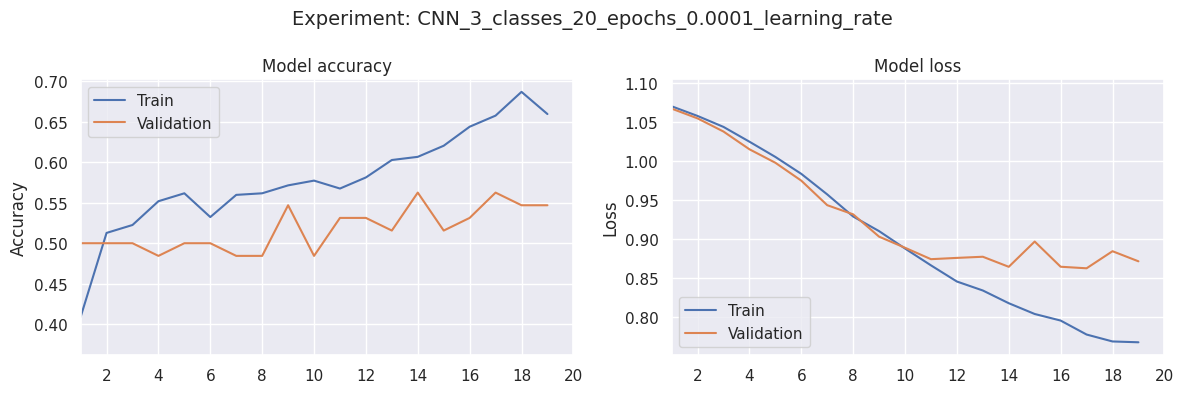

2026-04-30 20:04:07,576 [INFO] Précision finale de l'entraînement: 0.6595
2026-04-30 20:04:07,578 [INFO] Précision finale de la validation: 0.5469
2026-04-30 20:04:07,579 [INFO] Loss finale de l'entraînement: 0.7671
2026-04-30 20:04:07,579 [INFO] Loss finale de la validation: 0.8712


In [ ]:
path_to_model = f'models/from_scratch/{experiment_name}_model.keras'
path_to_history = f'models/from_scratch/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location=['upper left', 'lower left'])
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

In [10]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")

2026-04-30 20:04:07,587 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.6094 - loss: 0.8215


2026-04-30 20:04:07,881 [INFO] loss, accuracy = [0.8214526772499084, 0.609375]


#### 1.f) Entraînement à 3 classes avec 3 couches, avec 32, 64, et 128 filtres (au lieu de 32 et 64)

In [16]:
FILTERS = [32, 64, 128]
LR = 1e-3
N_CLASSES = 3
N_EPOCHS = 20
experiment_name = f'CNN_{N_CLASSES}_classes_{N_EPOCHS}_epochs_{len(FILTERS)}_layers'

Construire le modèle :

In [17]:
model = build_model_from_scratch(
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    filters=FILTERS,
    experiment_name=experiment_name,
)

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_3_classes_20_epochs_3_layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,475,523 (196.36 MB)

 Trainable params: 51,475,523 (196.36 MB)

 Non-trainable params: 0 (0.00 B)

None

Entraînement et validation :

In [8]:
torch.cuda.empty_cache()

2026-04-30 20:07:54,583 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_3_layers'...
W0000 00:00:1777572476.534082 2862777 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-04-30 20:08:49,953 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_3_layers' terminé
2026-04-30 20:08:49,954 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_3_layers_model.keras'
2026-04-30 20:08:52,180 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_3_layers_history.joblib'


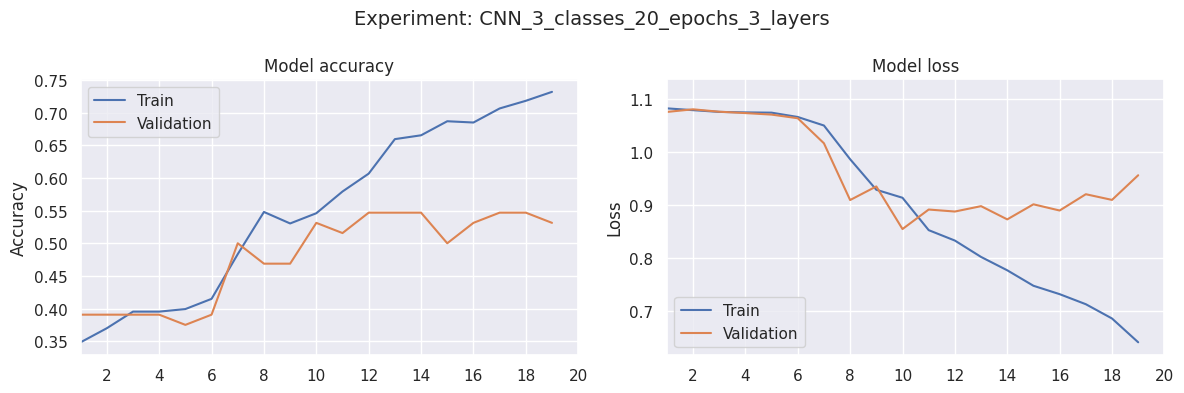

2026-04-30 20:08:55,281 [INFO] Précision finale de l'entraînement: 0.7319
2026-04-30 20:08:55,282 [INFO] Précision finale de la validation: 0.5312
2026-04-30 20:08:55,283 [INFO] Loss finale de l'entraînement: 0.6416
2026-04-30 20:08:55,284 [INFO] Loss finale de la validation: 0.9558


In [ ]:
path_to_model = f'models/from_scratch/{experiment_name}_model.keras'
path_to_history = f'models/from_scratch/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location=['upper left', 'lower left'])
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

In [10]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")

2026-04-30 20:08:55,291 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.6250 - loss: 0.8786


2026-04-30 20:08:55,594 [INFO] loss, accuracy = [0.8785918354988098, 0.625]


#### 1.g) Entraînement à 3 classes avec une fenêtre de balayage de 5 × 5 (au lieu de 3 × 3)

In [18]:
KERNEL_SIZE = 5
LR = 1e-3
N_CLASSES = 3
N_EPOCHS = 20
experiment_name = f'CNN_{N_CLASSES}_classes_{N_EPOCHS}_epochs_{KERNEL_SIZE}x{KERNEL_SIZE}_window'

Construire le modèle :

In [19]:
model = build_model_from_scratch(
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    kernel_size=KERNEL_SIZE,
    experiment_name=experiment_name,
)

model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Model: "CNN_3_classes_20_epochs_5x5_window"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 112, 112, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │   102,760,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,816,195 (392.21 MB)

 Trainable params: 102,816,195 (392.21 MB)

 Non-trainable params: 0 (0.00 B)

None

Entraînement et validation :

In [8]:
torch.cuda.empty_cache()

2026-04-30 20:05:21,073 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_5x5_window'...
W0000 00:00:1777572322.962047 2854508 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-04-30 20:06:21,732 [INFO] Entraînement du modèle 'CNN_3_classes_20_epochs_5x5_window' terminé
2026-04-30 20:06:21,733 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_5x5_window_model.keras'
2026-04-30 20:06:26,230 [INFO] Sauvegarder l'objet 'models/CNN_3_classes_20_epochs_5x5_window_history.joblib'


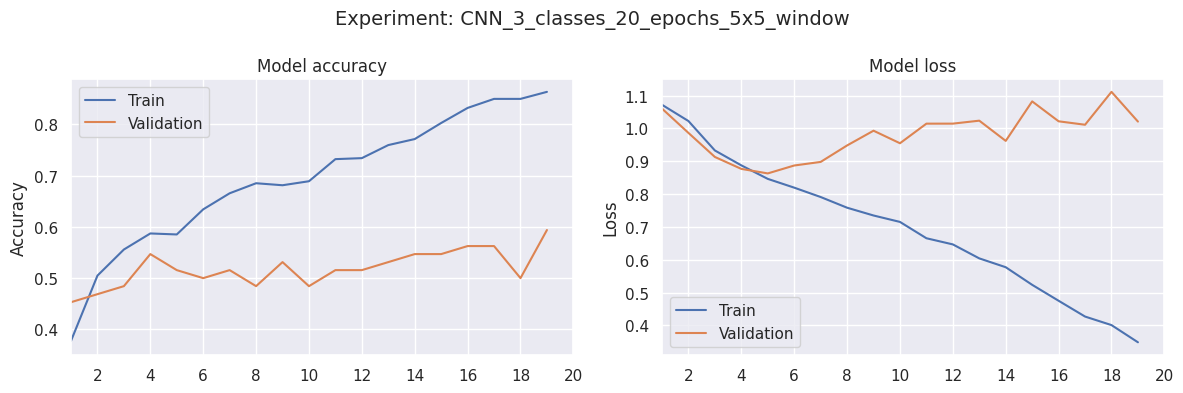

2026-04-30 20:06:33,558 [INFO] Précision finale de l'entraînement: 0.8630
2026-04-30 20:06:33,560 [INFO] Précision finale de la validation: 0.5938
2026-04-30 20:06:33,561 [INFO] Loss finale de l'entraînement: 0.3488
2026-04-30 20:06:33,561 [INFO] Loss finale de la validation: 1.0209


In [ ]:
path_to_model = f'models/from_scratch/{experiment_name}_model.keras'
path_to_history = f'models/from_scratch/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location=['upper left', 'lower left'])
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

In [10]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")

2026-04-30 20:06:33,570 [INFO] Évaluation sur les données de test :


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5469 - loss: 1.1476


2026-04-30 20:06:33,856 [INFO] loss, accuracy = [1.1476190090179443, 0.546875]


## Effectuer le monitoring à l'aide de TensorBoard

Pour chaque entraînement effectué, nous avons sauvegardé des logs pour TensorBoard à l'aide des callbacks. Voici comment les utiliser :

0. Activer le venv (si ce n'est pas déjà fait).

1. Lancer le serveur TensorBoard (avec `uv` comme gestionnaire de dépendances) :
   
   ```bash
   uv run --no-project tensorboard --logdir=log
   ```
   
   (où la valeur du paramètre `--logdir` est le chemin vers le répertoire avec les callbacks sauvegardés)

2. Cliquer sur le lien affiché. Par défaut, c'est [http://localhost:6006/](http://localhost:6006/).